# Assignment 1: Supervised Learning

**Course:** Machine Learning Fundamentals

**Total Points:** 100 (To be Scaled)

## General Instructions

1.  **Datasets**
    *   `server_performance_student.csv`: For regression analysis.
    *   `fraud_detection_student.csv`: For classification analysis.

2.  **Submission**
    *   Submit this `.ipynb` file only.
    *   Do not modify function signatures.
    *   Ensure all code cells run successfully.
    *   Do not hardcode the numbers in the returned dictionary
    *   Please do not include any commands like `!pip install numpy` because they may break the conversion process and therefore the submission will not be graded.
  
   - **File Naming Convention:**  
  - Use **your university email as the filename**, e.g.,  
    ```
    j.doe@innopolis.university.ipynb
    ```
  - **Do NOT modify this format**, or your submission may not be graded.

🔹 **Assignment Breakdown:**
| Task | Description | Points |
|------|------------|--------|
| **Task 1.1** | Linear and Polynomial Regression | 30 |
| **Task 2.1** | Data Preprocessing | 20 |
| **Task 2.2** | Classificaiton | 30 |
| **Task 2.3** | Thresholding | 20 |
| **Total** | - | **100** |

---

3.  **Grading**
    *   Your code will be graded automatically.
    *   **Requirement:** You must use `random_state=2026` for all data splitting and model initialization.

## Required Libraries

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import pandas as pd
import numpy as np
from typing import Dict, Tuple, Any

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import f1_score, recall_score, precision_score

# GLOBAL RANDOM STATE
RANDOM_STATE = 2026

In [35]:
server_df = pd.read_csv('sample_data/server_performance_student.csv')
fraud_df = pd.read_csv('sample_data/fraud_detection_student.csv')

## Task 1: Regression (30 Points)

**Objective:** Predict server latency based on concurrent requests.

**Requirements:**
1.  Load `server_performance_student.csv`.
2.  Split the data into Training (80%) and Testing (20%) sets using `random_state=2026`.
3.  Train a **Linear Regression** model.
4. plot the data to analyze and  see why your Linear model fail?
4.  Train a **Polynomial Regression** model using `GridSearchCV` to find the optimal degree (search range: 2 to 5).
5.  Return the metrics in the dictionary format specified below.

**Grading Criteria:**
*   RMSE < 120: Excellent (30/30)
*   RMSE < 180: Very Good (28/30)
*   RMSE < 250: Good (25/30)
*   RMSE < 350: Acceptable (15/30)
*   RMSE ≥ 350: Poor performance

In [36]:
def task1_regression(df: pd.DataFrame) -> Dict[str, Any]:
    """
    Performs linear and polynomial regression.

    Parameters:
        df (pd.DataFrame): DataFrame containing 'Concurrent_Requests' and 'Latency_ms'.

    Returns:
        Dict[str, Any]:
            - 'linear_model': Trained LinearRegression object.
            - 'linear_metrics': Dict {'mse', 'rmse', 'mae', 'r2'}.
            - 'poly_model': Trained polynomial Pipeline object.
            - 'poly_degree': Best degree (int).
            - 'poly_metrics': Dict {'mse', 'rmse', 'mae', 'r2'}.
    """

    # YOUR CODE HERE
    X = df[['Concurrent_Requests']]
    y = df['Latency_ms']
    X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=RANDOM_STATE
    )
    linear_model = LinearRegression()
    linear_model.fit(X_train, y_train)
    y_pred_linear = linear_model.predict(X_test)
    linear_metrics = {
    'mse': mean_squared_error(y_test, y_pred_linear),
    'rmse': np.sqrt(mean_squared_error(y_test, y_pred_linear)),
    'mae': mean_absolute_error(y_test, y_pred_linear),
    'r2': r2_score(y_test, y_pred_linear)
    }

    df_sorted = df.sort_values(by='Concurrent_Requests')
    ax = df.plot.scatter(x='Concurrent_Requests', y='Latency_ms', alpha=0.5, figsize=(10,6))
    ax.plot(df_sorted['Concurrent_Requests'],
            linear_model.predict(df_sorted[['Concurrent_Requests']]),
            color='red', linewidth=2)
    ax.set_title('Liner Model Fail')
    ax.grid(True)

    pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('linear', LinearRegression())
    ])
    param_grid = {
    'poly__degree': [2, 3, 4, 5]
    }
    grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error'
    )
    grid_search.fit(X_train, y_train)
    poly_model = grid_search.best_estimator_
    poly_degree = grid_search.best_params_['poly__degree']
    y_pred_poly = poly_model.predict(X_test)

    poly_metrics = {
    'mse': mean_squared_error(y_test, y_pred_poly),
    'rmse': np.sqrt(mean_squared_error(y_test, y_pred_poly)),
    'mae': mean_absolute_error(y_test, y_pred_poly),
    'r2': r2_score(y_test, y_pred_poly)
    }

    return {
        'linear_model': linear_model,
        'linear_metrics': linear_metrics,
        'poly_model': poly_model,
        'poly_degree': poly_degree,
        'poly_metrics': poly_metrics
    }

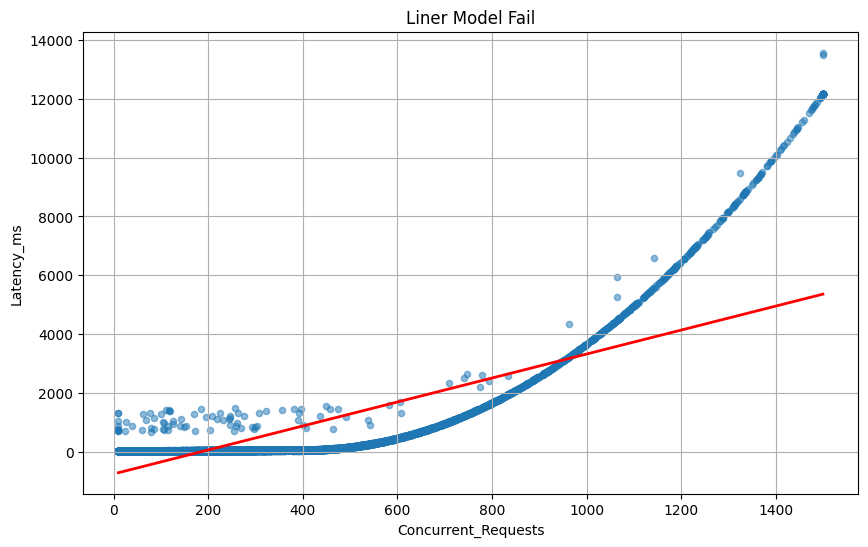

In [37]:
results = task1_regression(server_df)

## Task 2: Classification (70 Points)

### Task 2.1: Data Preprocessing (20 Points)

**Objective:** Clean and prepare the `fraud_detection_student.csv` dataset.

**Requirements:**
1.  **Leakage Removal:** Identify and drop the column that represents data leakage (information available only after fraud determination).
2.  **Feature Engineering:** Create a new binary feature `is_high_risk` from `IP_Address` (1 if starts with `192.168.0`, else 0). Drop original IP column.
3.  **Data Splitting:** Split into Train (80%) and Test (20%) using `random_state=2026` and `stratify`.
4.  **Scaling:** Apply `StandardScaler`.
5.  **Output:** Return the processed numpy arrays.

In [38]:
def task2_preprocessing(df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Preprocesses fraud data.

    Parameters:
        df (pd.DataFrame): Raw fraud detection dataset.

    Returns:
        Tuple: (X_train_scaled, X_test_scaled, y_train, y_test)
    """

    df = df.drop(columns=['Transaction_ID', 'Transaction_Status'])
    df['is_high_risk'] = df['IP_Address'].apply(
        lambda ip: 1 if str(ip).startswith('192.168.0') else 0
    )
    df = df.drop(columns=['IP_Address'])

    X = df.drop(columns=['Is_Fraud'])
    y = df['Is_Fraud']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, y_train.values, y_test.values

### Task 2.2: Model Training (30 Points)

**Objective:** Train three classifiers to detect fraud and compare their performance.

**Instructions:**
1.  Use the `X_train_scaled`, `X_test_scaled`, `y_train`, `y_test` variables returned from Task 2.1.
2.  **Logistic Regression:** Use `class_weight='balanced'` to handle class imbalace.
3.  **K-Nearest Neighbors:** Tune `n_neighbors` (3-9) using GridSearchCV. Use `weights='distance'` to handle class imbalace.
4.  **Naive Bayes:** Use `priors=[0.5, 0.5]` to handle class imbalace.
5.  Evaluate all models using **F1-Score at default threshold (0.5)**.
6.  Return all three trained models and their F1 scores.

**Grading Criteria (based on best F1 at default threshold):**
*   F1 ≥ 0.62: Excellent (30/30)
*   F1 ≥ 0.60: Very Good (28/30)
*   F1 ≥ 0.55: Good (25/30)
*   F1 ≥ 0.40: Acceptable (20/30)
*   F1 < 0.40: Poor performance

In [39]:
def task2_train_models(X_train: np.ndarray, X_test: np.ndarray, y_train: np.ndarray, y_test: np.ndarray) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    """
    Trains three classifiers.

    Returns:
        models (Dict): {'logreg': model, 'knn': model, 'nb': model}
        metrics (Dict): {
            'logreg_f1': float,
            'knn_f1': float,
            'nb_f1': float
        }
    """

     # YOUR CODE HERE
    logreg = LogisticRegression(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        max_iter=1000
    )
    logreg.fit(X_train, y_train)
    y_pred_logreg = logreg.predict(X_test)
    logreg_f1 = f1_score(y_test, y_pred_logreg)

    knn_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(weights='distance'))
    ])

    param_grid = {
        'knn__n_neighbors': [3, 5, 7, 9]
    }

    grid_search_knn = GridSearchCV(
        knn_pipeline,
        param_grid,
        cv=5,
        scoring='f1',
        n_jobs=-1
    )

    grid_search_knn.fit(X_train, y_train)
    best_knn = grid_search_knn.best_estimator_
    y_pred_knn = best_knn.predict(X_test)
    knn_f1 = f1_score(y_test, y_pred_knn)

    print(f"Лучший KNN с n_neighbors={grid_search_knn.best_params_['knn__n_neighbors']}")

    nb = GaussianNB(priors=[0.5, 0.5])
    nb.fit(X_train, y_train)
    y_pred_nb = nb.predict(X_test)
    nb_f1 = f1_score(y_test, y_pred_nb)

    models_dict = {
        'logreg': logreg,
        'knn': best_knn,
        'nb': nb
    }

    metrics_dict = {
        'logreg_f1': logreg_f1,
        'knn_f1': knn_f1,
        'nb_f1': nb_f1
    }

    return models_dict, metrics_dict

### Task 2.3: Threshold Tuning for Logistic Regression (20 Points)

**Objective:** Improve Logistic Regression performance through threshold optimization.

**Context:** You may have noticed that Logistic Regression had the lowest F1-score at the default threshold (0.5) but for imbalanced datasets like fraud detection, the decision threshold can significantly impact performance.

**Instructions:**
1.  Take the Logistic Regression model from Task 2.2.
2.  Predict probabilities on the Test Set using `predict_proba`.
3.  Iterate through different thresholds (based on your decision, for example 0.01 to 0.99) to find the one that maximizes F1-Score.
4.  Return the optimal threshold and the improved F1-Score.

**Grading Criteria:**
*   Optimized F1 ≥ 0.65: Excellent (20/20)
*   Optimized F1 ≥ 0.60: Very Good (18/20)
*   Optimized F1 ≥ 0.55: Good (15/20)
*   Optimized F1 ≥ 0.50: Acceptable (10/20)
*   Optimized F1 < 0.50: Poor performance

In [40]:
def task2_threshold_tuning(logreg_model: Any, X_test: np.ndarray, y_test: np.ndarray) -> Dict[str, float]:
    """
    Finds the best threshold for Logistic Regression.

    Parameters:
        logreg_model: The trained Logistic Regression model from Task 2.2, you need to re-train it
        X_test, y_test: Test data from Task 2.1

    Returns:
        Dict: {'best_threshold': float, 'optimized_f1': float}
    """

    # YOUR CODE HERE
    y_proba = logreg_model.predict_proba(X_test)[:, 1]

    best_f1 = 0
    best_threshold = 0.5

    for threshold in np.arange(0.01, 1.0, 0.01):
        y_pred_thresh = (y_proba > threshold).astype(int)

        current_f1 = f1_score(y_test, y_pred_thresh)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = threshold

    return {'best_threshold': best_threshold, 'optimized_f1': best_f1}